Import libary and Load Dataset

In [1]:
import pandas as pd
import numpy as np

# Load Data
df = pd.read_csv('online-gaming.csv', sep='\t')

# Menentukan target berdasarkan median (1: Populer, 0: Niche)
median_likes = df['likes'].median()
df['popularity_label'] = (df['likes'] > median_likes).astype(int)
print(f"Dataset loaded: {df.shape[0]} rows")
print(f"Threshold Popularity (Median): {median_likes} likes")

Dataset loaded: 11406 rows
Threshold Popularity (Median): 39.0 likes


In [2]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11406 entries, 0 to 11405
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              11406 non-null  object 
 1   url               11406 non-null  object 
 2   likes             11406 non-null  int64  
 3   dislikes          11406 non-null  int64  
 4   log_likes         11406 non-null  float64
 5   log_dislikes      11406 non-null  float64
 6   description       10146 non-null  object 
 7   tags              11372 non-null  object 
 8   popularity_label  11406 non-null  int32  
dtypes: float64(2), int32(1), int64(2), object(4)
memory usage: 757.6+ KB
None
               name                                     url   likes  dislikes  \
0   100 Metres Race   https://poki.com/en/g/100-meters-race   59500     14800   
1         100% Golf          https://poki.com/en/g/100-golf   21400      5100   
2  1010 Color Match  https://poki.com/en/g/1010-color

EDA Profesional & Export Data

✅ Seluruh data (11406 baris) telah berhasil disimpan ke 'seluruh_data_game_berdasarkan_likes.csv'.


C:\Users\User\AppData\Local\Temp\ipykernel_12612\3192503247.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='likes', y='name', data=top_10, palette='magma')


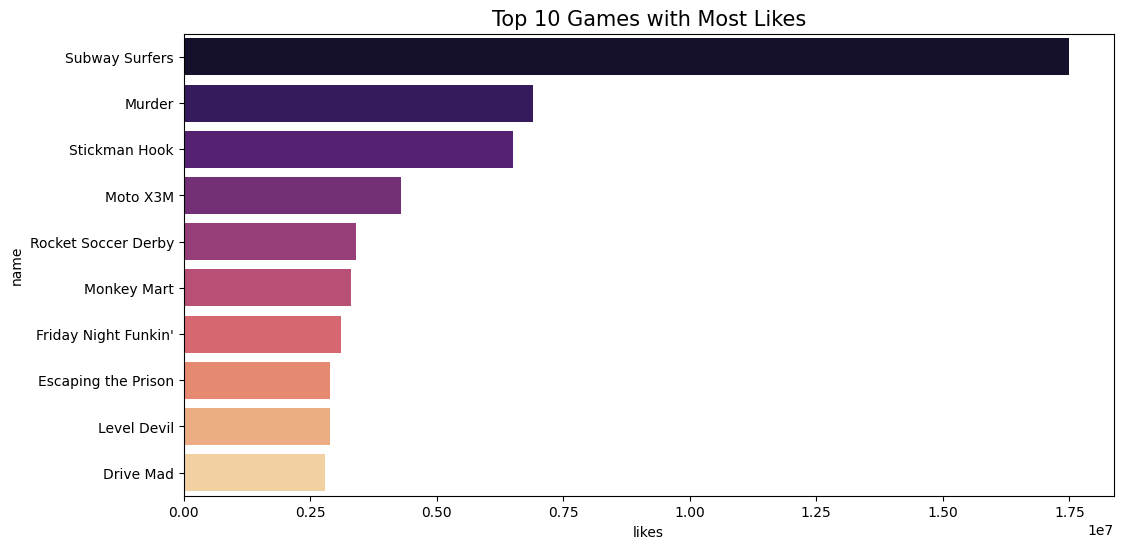

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi tetap menampilkan Top 10 untuk estetika chart
top_10 = df.nlargest(10, 'likes')

# --- PERUBAHAN: MENYIMPAN SELURUH GAME DALAM DATASET KE CSV ---
df_sorted = df.sort_values(by='likes', ascending=False)
df_sorted.to_csv('seluruh_data_game_berdasarkan_likes.csv', index=False)
print(f"✅ Seluruh data ({df_sorted.shape[0]} baris) telah berhasil disimpan ke 'seluruh_data_game_berdasarkan_likes.csv'.")

plt.figure(figsize=(12, 6))
sns.barplot(x='likes', y='name', data=top_10, palette='magma')
plt.title('Top 10 Games with Most Likes', fontsize=15)
plt.show()

Pre-processing

In [4]:
df['combined_text'] = df['name'].fillna('') + " " + df['description'].fillna('') + " " + df['tags'].fillna('')

Train and Test Split

In [5]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['combined_text'], df['popularity_label'], test_size=0.2, random_state=42, stratify=df['popularity_label']
)

Feature Engineering

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=2500, stop_words='english', ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

Model Building (Logistic Regression)

In [7]:
# Menggunakan Logistic Regression sesuai instruksi Anda sebelumnya
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Model Evaluation (Visual Report)

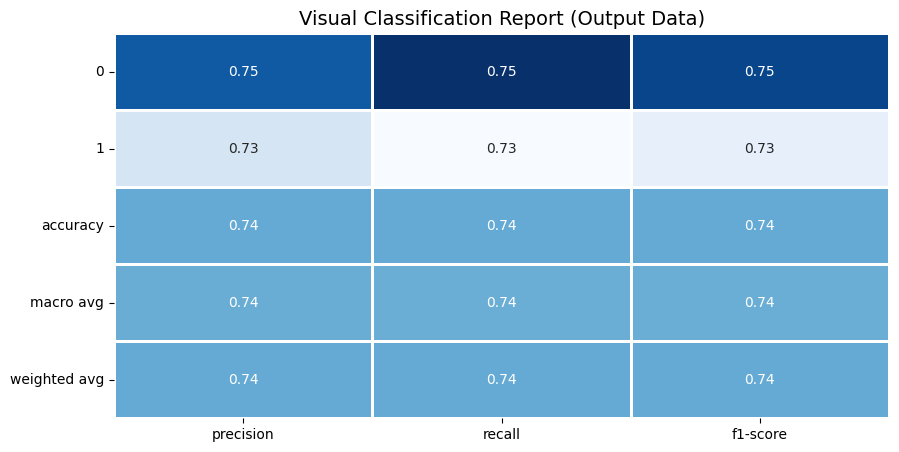

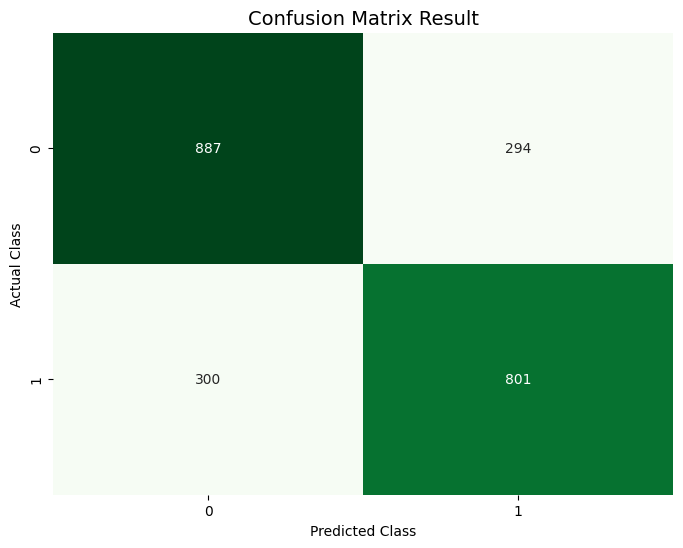

In [8]:
# Model Evaluation & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model_lr.predict(X_test)

# 1. Visual Classification Report (Data Output 0 & 1)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :].T 

plt.figure(figsize=(10, 5))
sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.2f', cbar=False, linewidths=2)
plt.title('Visual Classification Report (Output Data)', fontsize=14)
plt.show()

# 2. Confusion Matrix (Data Hasil)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix Result', fontsize=14)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

Learning Curve Overfitting

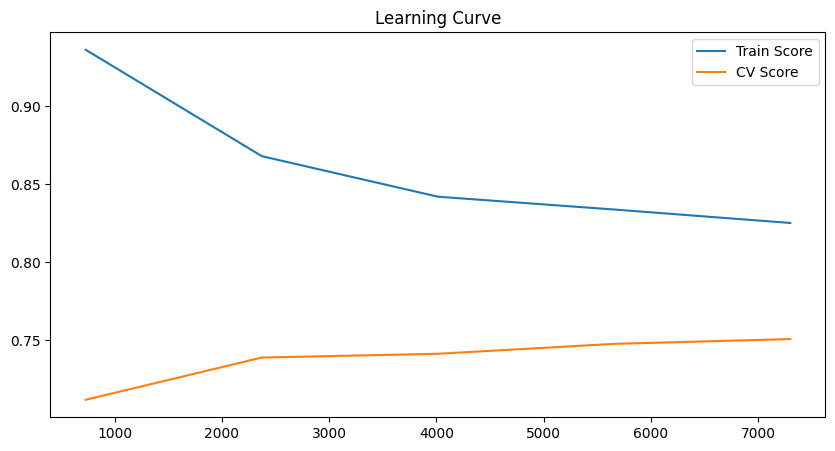

In [9]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(model_lr, X_train, y_train, cv=5)
plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='CV Score')
plt.title('Learning Curve')
plt.legend()
plt.show()

Cross Validation

In [10]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_lr, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {scores.mean():.4f}")

Cross-Validation Accuracy: 0.7507


Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10]}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

Feature Importance

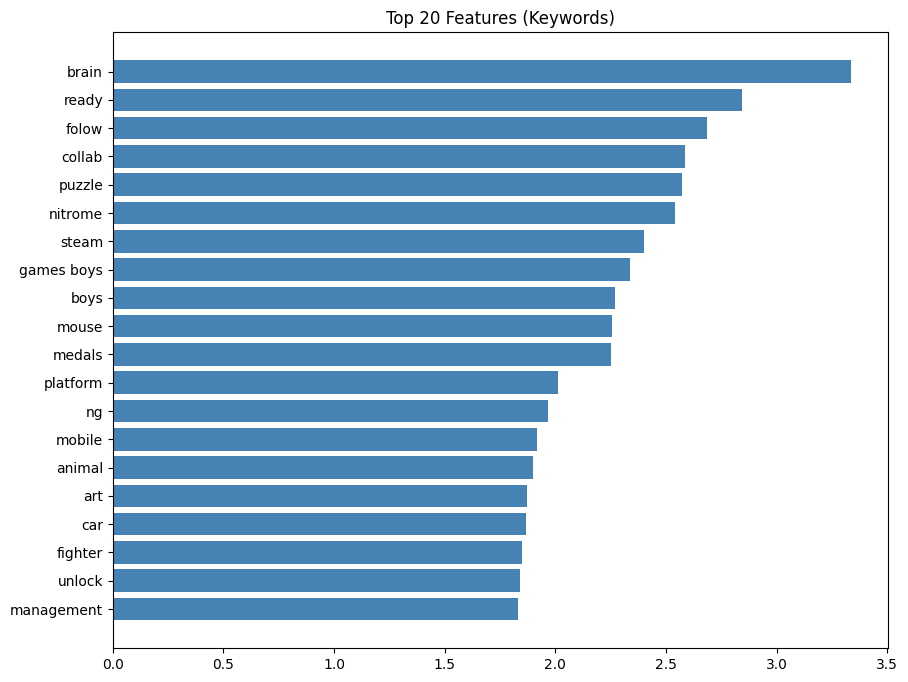

In [12]:
importance = best_model.coef_[0]
feature_names = tfidf.get_feature_names_out()
indices = np.argsort(importance)[-20:]

plt.figure(figsize=(10, 8))
plt.title('Top 20 Features (Keywords)')
plt.barh(range(len(indices)), importance[indices], align='center', color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.show()